     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  04-09-2012       58       635         88              546              172   
1  08-03-2014       38        11          1                6                2   
2  21-08-2013       26       426         49              127              111   
3  10-02-2014       26        11          4               20               10   
4  19-01-2014       94       173         43              118               46   

   MntSweetProducts  MntGoldProds  NumDealsP

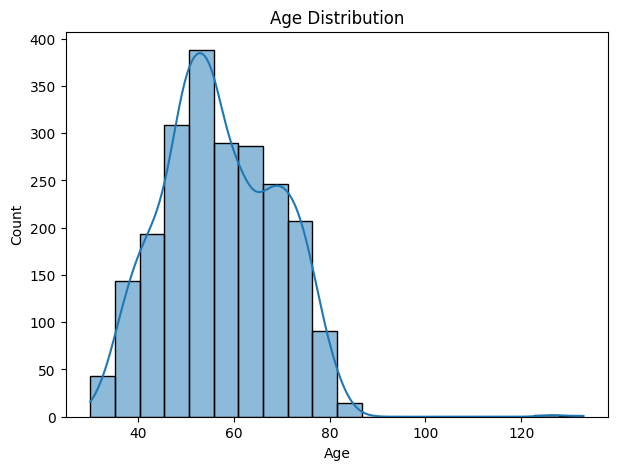

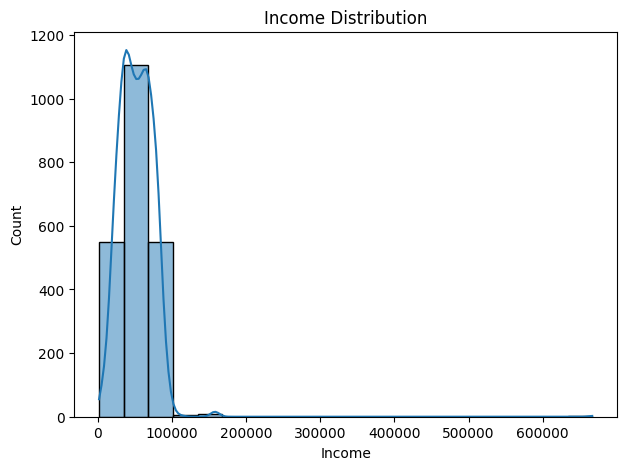

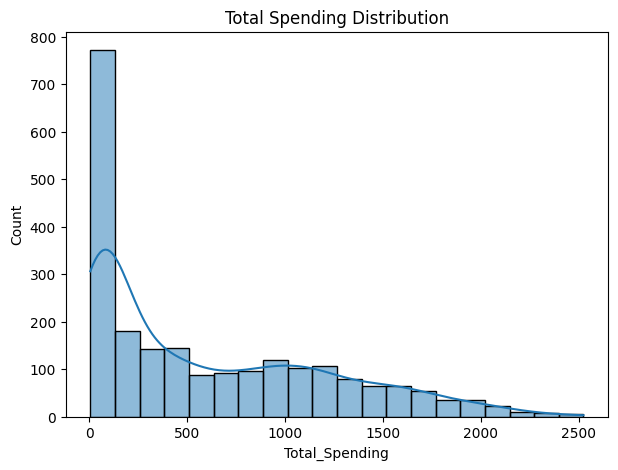

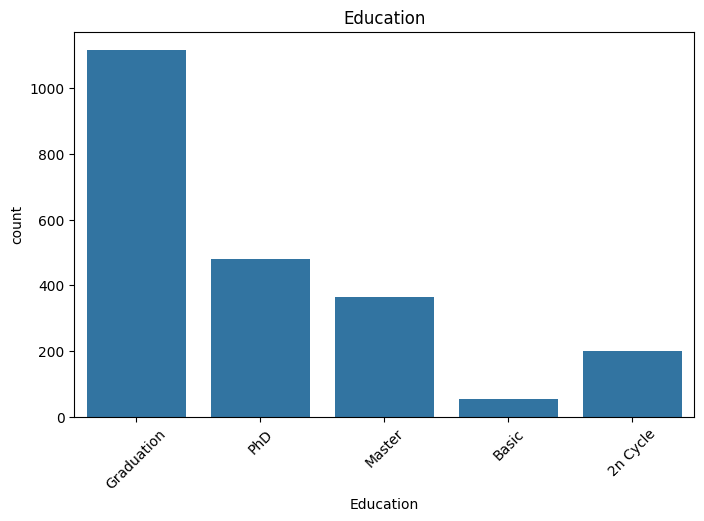

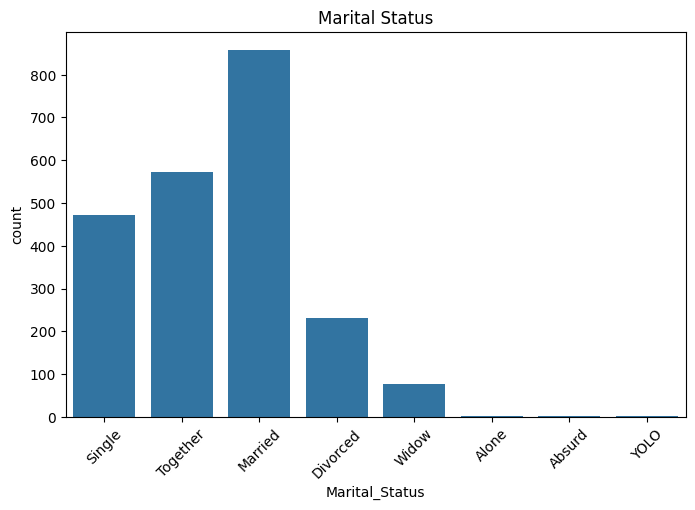

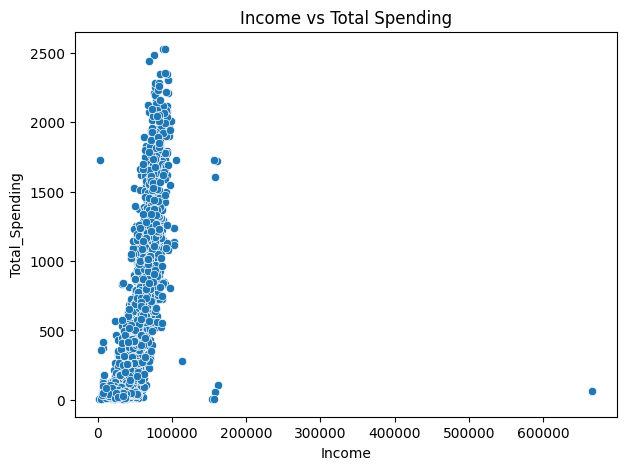

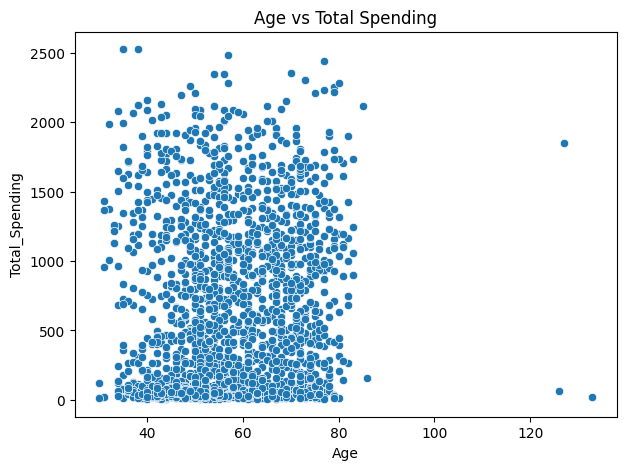

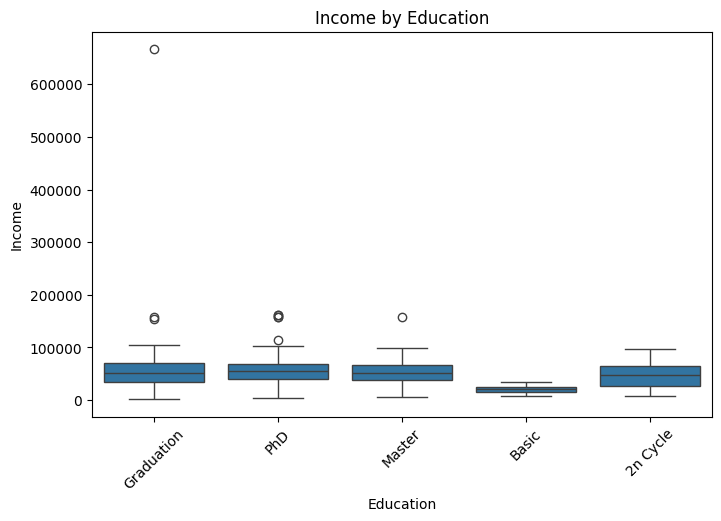

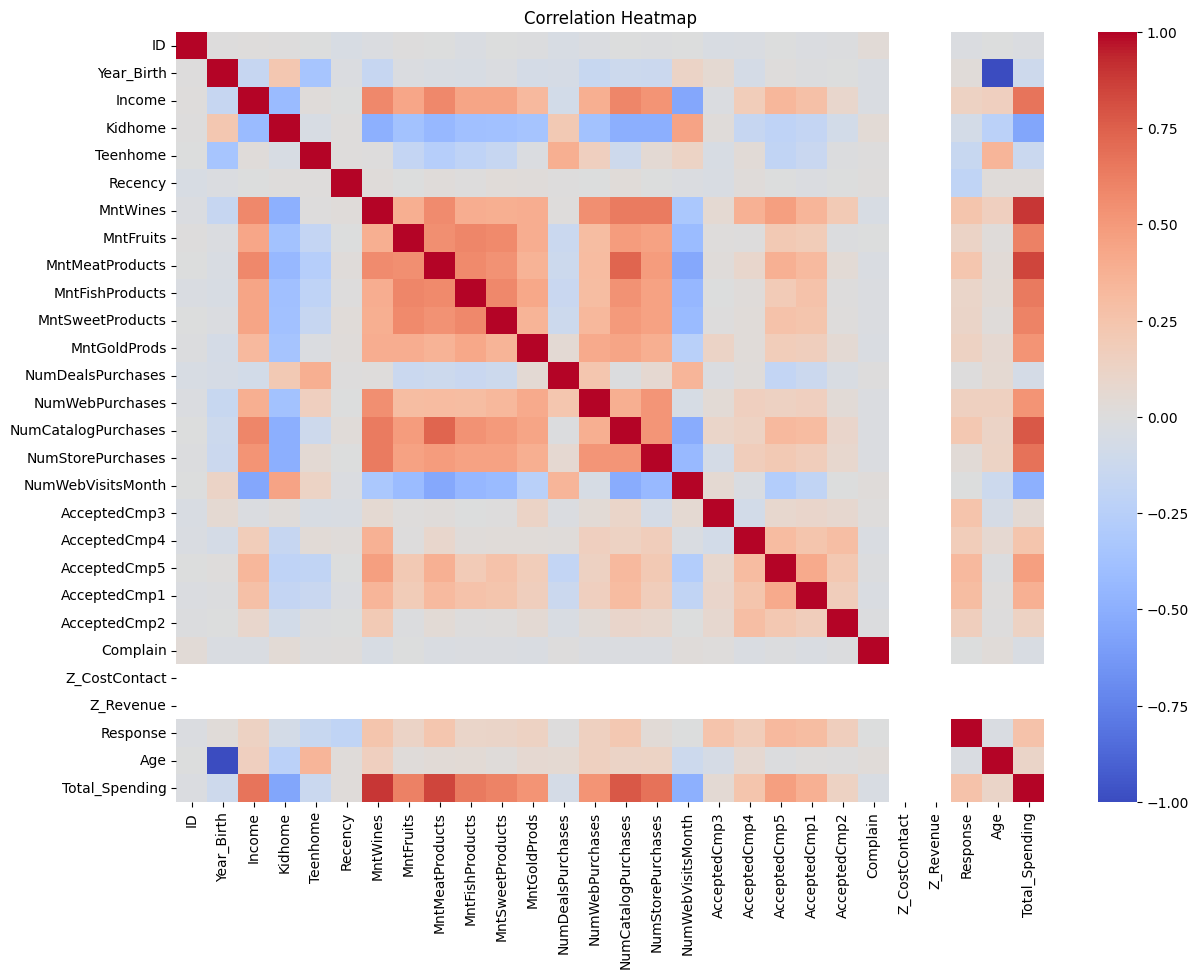

In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load Dataset
df = pd.read_csv("marketing_campaign.csv")
# Basic Information
print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())
# Missing Values
print(df.isnull().sum())
# Duplicate Values
print("Duplicate Rows :", df.duplicated().sum())
# Data Cleaning

# Remove missing values
df = df.dropna()

# Convert date column
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Customer Age
df["Age"] = 2026 - df["Year_Birth"]

# Total Spending
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)
# Distribution Plots
plt.figure(figsize=(7,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df["Income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df["Total_Spending"], bins=20, kde=True)
plt.title("Total Spending Distribution")
plt.show()
# Count Plots
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Education")
plt.xticks(rotation=45)
plt.title("Education")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Marital_Status")
plt.xticks(rotation=45)
plt.title("Marital Status")
plt.show()
# Scatter Plots
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="Income",
                y="Total_Spending")
plt.title("Income vs Total Spending")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="Age",
                y="Total_Spending")
plt.title("Age vs Total Spending")
plt.show()
# Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="Education",
            y="Income")
plt.xticks(rotation=45)
plt.title("Income by Education")
plt.show()
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Feature Engineering

df = df.copy()

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y",
    errors="coerce"
)

df = df.dropna(subset=["Income", "Dt_Customer"]).copy()

df["Age"] = 2026 - df["Year_Birth"]

df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Customer_Years"] = 2026 - df["Dt_Customer"].dt.year

df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

print(df[[
    "Income",
    "Age",
    "Children",
    "Customer_Years",
    "Total_Spending"
]].head())

    Income  Age  Children  Customer_Years  Total_Spending
0  58138.0   69         0              14            1617
1  46344.0   72         2              12              27
2  71613.0   61         0              13             776
3  26646.0   42         1              12              53
4  58293.0   45         1              12             422


In [36]:
from sklearn.preprocessing import StandardScaler

features = df[[
    "Income",
    "Age",
    "Children",
    "Customer_Years",
    "Total_Spending"
]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)
print(scaled_features[:5])

[[ 0.2340627   0.98644293 -1.26480327  1.50034282  1.67548812]
 [-0.23455948  1.23680074  1.40580564 -1.41739276 -0.96235832]
 [ 0.76947764  0.31882209 -1.26480327  0.04147503  0.28024985]
 [-1.01723878 -1.2667774   0.07050118 -1.41739276 -0.91922372]
 [ 0.24022146 -1.01641959  0.07050118 -1.41739276 -0.30704427]]


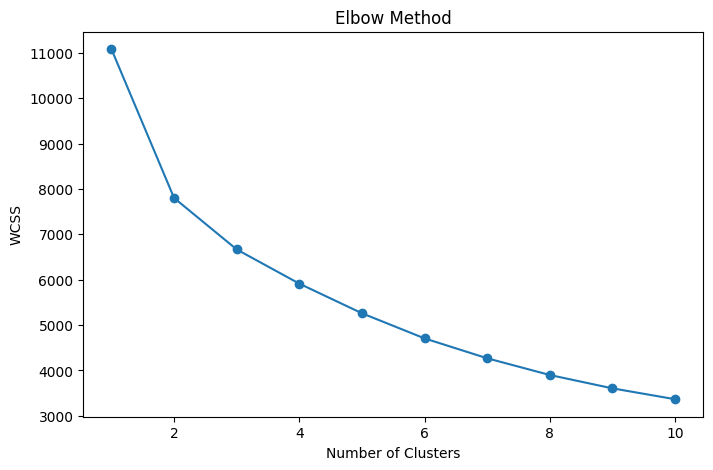

In [30]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [32]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

print(df["Cluster"].value_counts())

Cluster
3    714
2    544
1    508
0    450
Name: count, dtype: int64


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

df["PCA1"] = pca_result[:,0]
df["PCA2"] = pca_result[:,1]
print(pca.explained_variance_ratio_)

[0.40271145 0.21867658]


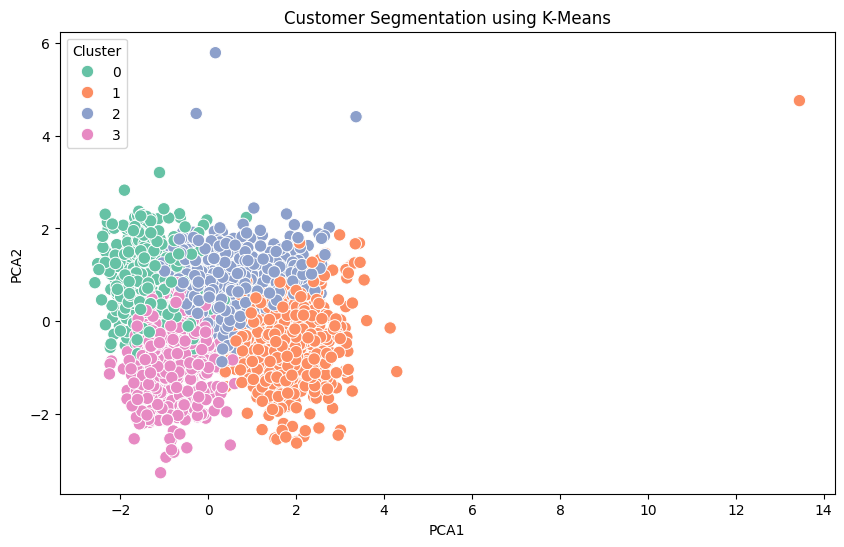

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation using K-Means")

plt.show()